# Phase 5 — Structured Extraction Accuracy

**Purpose:** Run the extraction pipeline (PAO regex + category classifier) on the same
20 test images from Phase 4, compare against ground truth, and report regex hit rate
and category accuracy.

**Prerequisites:**
- Docker API running (default `http://localhost:8000`)
- 20 product JPEGs in `backend/test_photos/`
- Google service account at `backend/credentials/shelf-love-353bbeca17ab.json`
- Ground truth CSV at `backend/test_photos/ground_truth.csv`

In [13]:
import sys, os, json, time, re
from pathlib import Path

import requests
import pandas as pd
from IPython.display import display, Markdown

# scikit-learn for confusion matrix (optional)
try:
    from sklearn.metrics import confusion_matrix, classification_report
    import matplotlib.pyplot as plt
    SKLEARN_OK = True
except ImportError:
    SKLEARN_OK = False

# Load extraction module directly from backend
BACKEND_DIR = Path.cwd().parent
sys.path.insert(0, str(BACKEND_DIR))
from app.services.extraction import extract_all

In [14]:
# === CONFIGURATION ===
API_BASE_URL = os.environ.get("API_BASE_URL", "http://localhost:8000")

TEST_EMAIL = "ocr_test@example.com"
TEST_PASSWORD = "test123"
TEST_NAME = "OCR Test"

NOTEBOOK_DIR = Path.cwd()
BACKEND_DIR = NOTEBOOK_DIR.parent
IMAGE_DIR = BACKEND_DIR / "test_photos"
GT_PATH = IMAGE_DIR / "ground_truth.csv"

IMAGE_EXTS = {".jpg", ".jpeg", ".png"}
image_paths = sorted([p for p in IMAGE_DIR.iterdir() if p.suffix.lower() in IMAGE_EXTS])

print(f"API: {API_BASE_URL}")
print(f"Images dir: {IMAGE_DIR}")
print(f"Images found: {len(image_paths)}")
print(f"Ground truth exists: {GT_PATH.exists()}")
print(f"Credentials exist: {(BACKEND_DIR / 'credentials' / 'shelf-love-353bbeca17ab.json').exists()}")

API: http://localhost:8000
Images dir: c:\Projects\cosmetic-expiry-scanner\backend\test_photos
Images found: 20
Ground truth exists: True
Credentials exist: True


In [15]:
# === LOGIN / REGISTER ===
def login_or_register(email, password, name):
    r = requests.post(f"{API_BASE_URL}/auth/login", json={"email": email, "password": password})
    if r.status_code == 200:
        print(f"Logged in as {email}")
        return r.json()["access_token"]
    print(f"Login failed ({r.status_code}), registering...")
    r = requests.post(f"{API_BASE_URL}/auth/register", json={"email": email, "password": password, "name": name})
    if r.status_code == 201:
        print(f"Registered as {email}, logging in...")
        r = requests.post(f"{API_BASE_URL}/auth/login", json={"email": email, "password": password})
        if r.status_code == 200:
            return r.json()["access_token"]
        raise RuntimeError(f"Login after register failed: {r.status_code} {r.text}")
    raise RuntimeError(f"Auth failed: {r.status_code} {r.text}")

TOKEN = login_or_register(TEST_EMAIL, TEST_PASSWORD, TEST_NAME)
HEADERS = {"Authorization": f"Bearer {TOKEN}"}
print("Token acquired")

Logged in as ocr_test@example.com
Token acquired


In [16]:
# === LOAD GROUND TRUTH ===

VALID_CATEGORIES = {"skincare", "haircare", "makeup"}

df_gt = pd.read_csv(GT_PATH)
df_gt["expected_pao_months"] = df_gt["expected_pao_months"].apply(
    lambda x: int(x) if pd.notna(x) and str(x).strip() != "" else None
)

# Validate categories
bad = df_gt[~df_gt["expected_category"].isin(VALID_CATEGORIES) & df_gt["expected_category"].notna()]
if len(bad):
    print("WARNING: rows with invalid categories (must be skincare/haircare/makeup):")
    display(bad[["filename", "expected_category"]])

display(df_gt[["filename", "brand", "product_name", "label_side",
              "expected_category", "expected_pao_months", "notes"]])

,filename,brand,product_name,label_side,expected_category,expected_pao_months,notes
0,01.jpeg,BIODERMA,Sensibio H2O Micellar Water,front,skincare,NaN,front panel — PAO symbol likely on back/bottle
1,02.jpeg,BIODERMA,Sensibio H2O Micellar Water,back,skincare,12.0,transparent label low contrast — PAO out of frame
2,03.jpeg,Sesderma,DRYSES Deodorant Roll-On,back,skincare,12.0,ingredients panel — 12M visible
3,04.jpeg,Sesderma,DRYSES Deodorant Roll-On,front,skincare,NaN,curved surface — edge text clipped
4,05.jpeg,L'Oreal Paris,Elvive Dream Lengths Shampoo,back,haircare,12.0,ingredients panel — 12M visible
5,06.jpeg,L'Oreal Paris,Elvive Dream Lengths Shampoo,front,haircare,NaN,front label only — no PAO visible
6,07.jpeg,Aveeno,Apple Cider Vinegar Shampoo,back,haircare,18.0,ingredients panel — 18M visible
7,08.jpeg,Aveeno,Apple Cider Vinegar Shampoo,front,haircare,NaN,front label only — no PAO visible
8,09.jpeg,Natasha Denona,Hyglam Concealer,back,makeup,12.0,blurry small PAO likely won't get picked up
9,10.jpeg,Natasha Denona,ND,front,makeup,NaN,only 17 OCR chars — brand name only


In [17]:
# === HELPER: UPLOAD IMAGE + RUN OCR + EXTRACTION ===
def upload_and_process(image_path, verbose=True):
    filename = image_path.name
    # 1) Get presigned upload URL
    r = requests.post(f"{API_BASE_URL}/uploads/presigned-url",
        json={"file_name": filename, "content_type": "image/jpeg"}, headers=HEADERS)
    r.raise_for_status()
    ud = r.json()
    # 2) Upload to S3
    with open(image_path, "rb") as f:
        data = f.read()
    r = requests.put(ud["upload_url"], data=data, headers={"Content-Type": "image/jpeg"})
    if r.status_code not in (200, 201, 204):
        raise RuntimeError(f"S3 upload failed: {r.status_code}")
    if verbose:
        print(f"  uploaded to S3: {ud['file_key']}")
    # 3) Process (OCR + extraction on backend)
    r = requests.post(f"{API_BASE_URL}/uploads/process",
        json={"file_key": ud["file_key"], "barcode": None}, headers=HEADERS)
    r.raise_for_status()
    pd_result = r.json()
    raw_text = pd_result.get("raw_ocr_text") or ""
    if verbose:
        print(f"  OCR done: {len(raw_text)} chars, scan_id={pd_result.get('scan_id')}")
    # 4) Run extraction locally on the raw text for consistency
    extraction = extract_all(raw_text)
    return {
        "filename": filename,
        "file_key": ud["file_key"],
        "scan_id": pd_result.get("scan_id"),
        "raw_ocr_text": raw_text,
        "ocr_length": len(raw_text),
        "pao_months": extraction["pao_months"],
        "category": extraction["category"],
        "category_method": extraction["category_method"],
        "extraction_method": extraction["extraction_method"],
        "success": True,
    }

In [18]:
# === RUN PIPELINE ON ALL IMAGES ===
results = []
print(f"Processing {len(image_paths)} images...\n")
for i, img_path in enumerate(image_paths, 1):
    print(f"[{i}/{len(image_paths)}] {img_path.name}")
    try:
        res = upload_and_process(img_path)
        results.append(res)
    except Exception as e:
        print(f"  ERROR: {e}")
        results.append({
            "filename": img_path.name, "file_key": None, "scan_id": None,
            "raw_ocr_text": "", "ocr_length": 0,
            "pao_months": None, "category": None,
            "category_method": None, "extraction_method": None,
            "success": False,
        })
    print()

ok = sum(1 for r in results if r["success"])
print(f"\nDone. {ok}/{len(results)} succeeded.")

Processing 20 images...

[1/20] 01.jpeg
  uploaded to S3: products/d80ba7fe-f22b-4aeb-9162-77925dc9f46a.jpeg
  OCR done: 299 chars, scan_id=127

[2/20] 02.jpeg
  uploaded to S3: products/d6202042-7a92-4663-b376-6c1f80379cc8.jpeg
  OCR done: 2693 chars, scan_id=128

[3/20] 03.jpeg
  uploaded to S3: products/e4c52549-15ca-4083-b3a2-78e4a3746ab4.jpeg
  OCR done: 747 chars, scan_id=129

[4/20] 04.jpeg
  uploaded to S3: products/77905a70-757e-446e-b579-5f8f77a8cc7f.jpeg
  OCR done: 227 chars, scan_id=130

[5/20] 05.jpeg
  uploaded to S3: products/3dd6a996-e73a-4f38-b0ae-76851e9c1815.jpeg
  OCR done: 1682 chars, scan_id=131

[6/20] 06.jpeg
  uploaded to S3: products/f92dc631-a6e4-4ae5-a8cb-544142fa834b.jpeg
  OCR done: 144 chars, scan_id=132

[7/20] 07.jpeg
  uploaded to S3: products/0774d5ff-cca8-4886-81e0-384b40971c2c.jpeg
  OCR done: 1641 chars, scan_id=133

[8/20] 08.jpeg
  uploaded to S3: products/27d65939-998c-4830-af71-abbaf460f3ab.jpeg
  OCR done: 345 chars, scan_id=134

[9/20] 09.jp

In [19]:
# === MERGE WITH GROUND TRUTH ===
df = pd.DataFrame(results)
df["preview"] = df["raw_ocr_text"].apply(
    lambda t: t.replace("\n", " ") if t else ""
)

# Merge ground truth on filename
df = df.merge(
    df_gt[["filename", "brand", "product_name", "label_side",
           "expected_category", "expected_pao_months"]],
    on="filename", how="left"
)

# Comparison flags
df["pao_match"] = df.apply(
    lambda r: r["pao_months"] == r["expected_pao_months"]
    if pd.notna(r["expected_pao_months"]) else None,
    axis=1
)
df["pao_false_positive"] = df.apply(
    lambda r: pd.notna(r["pao_months"]) and pd.isna(r["expected_pao_months"]),
    axis=1
)
df["category_match"] = df.apply(
    lambda r: r["category"] == r["expected_category"]
    if (pd.notna(r["expected_category"]) and pd.notna(r["category"])) else None,
    axis=1
)

# Summary table
display(df[["filename", "brand", "product_name", "label_side",
           "pao_months", "expected_pao_months", "pao_match",
           "extraction_method",
           "category", "expected_category", "category_match"]])

,filename,brand,product_name,label_side,pao_months,expected_pao_months,pao_match,extraction_method,category,expected_category,category_match
0,01.jpeg,BIODERMA,Sensibio H2O Micellar Water,front,NaN,NaN,None,not_found,skincare,skincare,True
1,02.jpeg,BIODERMA,Sensibio H2O Micellar Water,back,NaN,12.0,False,not_found,skincare,skincare,True
2,03.jpeg,Sesderma,DRYSES Deodorant Roll-On,back,12.0,12.0,True,regex_match,NaN,skincare,None
3,04.jpeg,Sesderma,DRYSES Deodorant Roll-On,front,NaN,NaN,None,not_found,NaN,skincare,None
4,05.jpeg,L'Oreal Paris,Elvive Dream Lengths Shampoo,back,12.0,12.0,True,regex_match,skincare,haircare,False
5,06.jpeg,L'Oreal Paris,Elvive Dream Lengths Shampoo,front,NaN,NaN,None,not_found,haircare,haircare,True
6,07.jpeg,Aveeno,Apple Cider Vinegar Shampoo,back,18.0,18.0,True,regex_match,haircare,haircare,True
7,08.jpeg,Aveeno,Apple Cider Vinegar Shampoo,front,NaN,NaN,None,not_found,skincare,haircare,False
8,09.jpeg,Natasha Denona,Hyglam Concealer,back,2.0,12.0,False,regex_match,skincare,makeup,False
9,10.jpeg,Natasha Denona,ND,front,NaN,NaN,None,not_found,NaN,makeup,None


In [20]:
# === EXTRA: RAW TEXT PREVIEW TABLE (mirroring Phase 4) ===
display(df[["filename", "success", "scan_id", "ocr_length", "preview"]])

,filename,success,scan_id,ocr_length,preview
0,01.jpeg,True,127,299,BIODERMA LABORATOIRE DERMATOLOGIQUE SENSIBIO H...
1,02.jpeg,True,128,2693,Physiob Unfragance DAF Advancedon esmicellaire...
2,03.jpeg,True,129,747,"INGREDIENTS: AQUA, ALUMINUM CHLOROHYDRATE, PPG..."
3,04.jpeg,True,130,227,and 2568 88 sesderma DRYSES Deodorant roll-on ...
4,05.jpeg,True,131,1682,Long Damaged Hair? based amino acids similar t...
5,06.jpeg,True,132,144,L L'ORÉAL PARIS ELVIVE DREAM LENGTHS SPLIT END...
6,07.jpeg,True,133,1641,APPLE CIDER VINEGAR BLEND CLARIFY & SHINE SHAM...
7,08.jpeg,True,134,345,NEW LOOKI SAME GREAT FORMULA Aveeno SCALP SOOT...
8,09.jpeg,True,135,433,X2M HYGLAM CONCEALER Brightening & Hydrating C...
9,10.jpeg,True,136,17,NATASHA DENONA ND


---
## Analysis

### 1. Regex Hit Rate

How many images produced a PAO match via regex vs `"not_found"`?

In [21]:
total = len(df)
regex_matches = df[df["extraction_method"] == "regex_match"]
not_found = df[df["extraction_method"] == "not_found"]
no_text = df[df["extraction_method"].isna()]

hit_count = len(regex_matches)
miss_count = len(not_found) + len(no_text)
hit_rate = hit_count / total * 100 if total else 0

print("=" * 60)
print("REGEX HIT RATE")
print("=" * 60)
print(f"  regex_match  (PAO found):  {hit_count:>2} / {total:>2}  ({hit_rate:.1f}%)")
print(f"  not_found    (PAO null):   {miss_count:>2} / {total:>2}  ({100 - hit_rate:.1f}%)\n")

print("PAO extracted:")
for _, r in regex_matches.iterrows():
    gt = int(r["expected_pao_months"]) if pd.notna(r["expected_pao_months"]) else "?"
    m = "✓" if r["pao_match"] else "✗"
    fp = " (FP!)" if r["pao_false_positive"] else ""
    print(f"  {r['filename']:>9} side={r['label_side']:<5}  → {int(r['pao_months'])}M  (expected={gt})  {m}{fp}")

print()
print("Null PAO (not_found):")
for _, r in not_found.iterrows():
    print(f"  {r['filename']:>9} side={r['label_side']:<5}  ocr_chars={r['ocr_length']}")

if len(no_text):
    print(f"\nNo OCR text:")
    for _, r in no_text.iterrows():
        print(f"  {r['filename']:>9}")

REGEX HIT RATE
  regex_match  (PAO found):   8 / 20  (40.0%)
  not_found    (PAO null):   12 / 20  (60.0%)

PAO extracted:
    03.jpeg side=back   → 12M  (expected=12)  ✓
    05.jpeg side=back   → 12M  (expected=12)  ✓
    07.jpeg side=back   → 18M  (expected=18)  ✓
    09.jpeg side=back   → 2M  (expected=12)  ✗
    11.jpeg side=back   → 18M  (expected=18)  ✓
    15.jpeg side=back   → 6M  (expected=12)  ✗
    17.jpeg side=back   → 6M  (expected=12)  ✗
    19.jpeg side=back   → 12M  (expected=12)  ✓

Null PAO (not_found):
    01.jpeg side=front  ocr_chars=299
    02.jpeg side=back   ocr_chars=2693
    04.jpeg side=front  ocr_chars=227
    06.jpeg side=front  ocr_chars=144
    08.jpeg side=front  ocr_chars=345
    10.jpeg side=front  ocr_chars=17
    12.jpeg side=front  ocr_chars=11
    13.jpeg side=back   ocr_chars=1128
    14.jpeg side=front  ocr_chars=102
    16.jpeg side=front  ocr_chars=210
    18.jpeg side=front  ocr_chars=266
    20.jpeg side=front  ocr_chars=177


### 2. Category Accuracy

Keyword-based classifier accuracy vs ground truth.

CATEGORY ACCURACY
  Correct:   9 / 16  (56.2%)

    01.jpeg: predicted=skincare   expected=skincare   ✓
    02.jpeg: predicted=skincare   expected=skincare   ✓
    05.jpeg: predicted=skincare   expected=haircare   ✗
    06.jpeg: predicted=haircare   expected=haircare   ✓
    07.jpeg: predicted=haircare   expected=haircare   ✓
    08.jpeg: predicted=skincare   expected=haircare   ✗
    09.jpeg: predicted=skincare   expected=makeup     ✗
    11.jpeg: predicted=makeup     expected=makeup     ✓
    13.jpeg: predicted=skincare   expected=makeup     ✗
    14.jpeg: predicted=skincare   expected=makeup     ✗
    15.jpeg: predicted=skincare   expected=makeup     ✗
    16.jpeg: predicted=skincare   expected=makeup     ✗
    17.jpeg: predicted=skincare   expected=skincare   ✓
    18.jpeg: predicted=skincare   expected=skincare   ✓
    19.jpeg: predicted=haircare   expected=haircare   ✓
    20.jpeg: predicted=haircare   expected=haircare   ✓

Misclassifications (7):
    05.jpeg: got 'skincare' → e

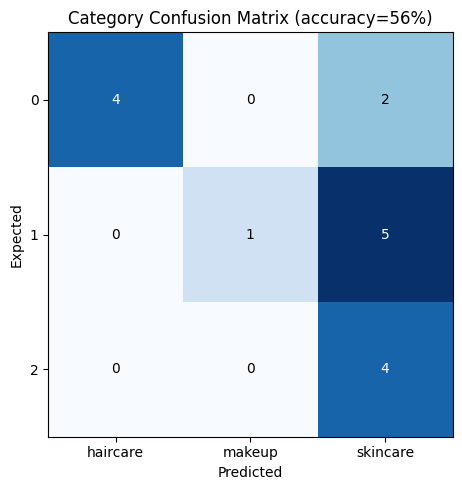


Classification Report:
              precision    recall  f1-score   support

    haircare       1.00      0.67      0.80         6
      makeup       1.00      0.17      0.29         6
    skincare       0.36      1.00      0.53         4

    accuracy                           0.56        16
   macro avg       0.79      0.61      0.54        16
weighted avg       0.84      0.56      0.54        16


Images with no category detected: 4
    03.jpeg  expected=skincare  ocr_chars=747
    04.jpeg  expected=skincare  ocr_chars=227
    10.jpeg  expected=makeup  ocr_chars=17
    12.jpeg  expected=makeup  ocr_chars=11


In [22]:
cat_df = df[df["category"].notna() & df["expected_category"].notna()].copy()

cat_total = len(cat_df)
cat_correct = (cat_df["category"] == cat_df["expected_category"]).sum()
cat_accuracy = cat_correct / cat_total * 100 if cat_total else 0

print("=" * 60)
print("CATEGORY ACCURACY")
print("=" * 60)
print(f"  Correct:  {cat_correct:>2} / {cat_total:>2}  ({cat_accuracy:.1f}%)\n")

for _, r in cat_df.iterrows():
    m = "✓" if r["category"] == r["expected_category"] else "✗"
    print(f"  {r['filename']:>9}: predicted={r['category']:<10} expected={r['expected_category']:<10} {m}")

errors = cat_df[cat_df["category"] != cat_df["expected_category"]]
if len(errors):
    print(f"\nMisclassifications ({len(errors)}):")
    for _, r in errors.iterrows():
        print(f"  {r['filename']:>9}: got '{r['category']}' → expected '{r['expected_category']}'")
else:
    print("\nNo misclassifications.")

# Confusion matrix
if SKLEARN_OK and cat_total > 0:
    labels = sorted(set(cat_df["expected_category"].unique()) | set(cat_df["category"].unique()))
    cm = confusion_matrix(cat_df["expected_category"], cat_df["category"], labels=labels)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Expected")
    ax.set_title(f"Category Confusion Matrix (accuracy={cat_accuracy:.0f}%)")
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.tight_layout()
    plt.show()
    print("\nClassification Report:")
    print(classification_report(cat_df["expected_category"], cat_df["category"],
                                labels=labels, zero_division=0))
elif cat_total > 0:
    print("\nInstall scikit-learn + matplotlib for confusion matrix visualization:")
    print("  pip install scikit-learn matplotlib")

# Images with no category detected
no_cat = df[df["category"].isna()]
if len(no_cat):
    print(f"\nImages with no category detected: {len(no_cat)}")
    for _, r in no_cat.iterrows():
        print(f"  {r['filename']:>9}  expected={r['expected_category']}  ocr_chars={r['ocr_length']}")

In [23]:
# === 3. FALSE POSITIVE CHECK ===
fp = df[df["pao_false_positive"] == True]

print("=" * 60)
print("FALSE POSITIVES — extracted PAO when none expected")
print("=" * 60)
if len(fp):
    for _, r in fp.iterrows():
        text = r["raw_ocr_text"]
        matches = re.findall(r"(\d+)\s*[Mm]\b", text)
        print(f"  {r['filename']:>9}: predicted {int(r['pao_months'])}M but expected null")
        print(f"           Regex hits in text: {matches}\n")
    print(f"  False positive rate: {len(fp)} / {len(df)}")
else:
    print("  None — all extracted PAO values match expected.")

FALSE POSITIVES — extracted PAO when none expected
  None — all extracted PAO values match expected.


---
## Detailed Extraction Output

In [24]:
for _, row in df.iterrows():
    print("=" * 60)
    print(f"FILE: {row['filename']}  (scan_id={row['scan_id']})")
    print(f"Brand:   {row['brand']}   Product: {row['product_name']}")
    print(f"Side:    {row['label_side']}")
    print("-" * 60)
    print(f"PAO:        {row['pao_months']}M (method: {row['extraction_method']})")
    print(f"Category:   {row['category']} (method: {row['category_method']})")
    print(f"Expected:   PAO={row.get('expected_pao_months', '?')}M, Cat={row.get('expected_category', '?')}")
    print("-" * 60)
    print(row["raw_ocr_text"] if row["raw_ocr_text"] else "(no text detected)")
    print()

FILE: 01.jpeg  (scan_id=127)
Brand:   BIODERMA   Product: Sensibio H2O Micellar Water
Side:    front
------------------------------------------------------------
PAO:        nanM (method: not_found)
Category:   skincare (method: keyword_match)
Expected:   PAO=nanM, Cat=skincare
------------------------------------------------------------
BIODERMA
LABORATOIRE DERMATOLOGIQUE
SENSIBIO
H2O
PEAUX SENSIBLES
SENSITIVE SKIN
L'eau micellaire Originale
Nettoie Démaquille - Apaise
Visage - Yeux
The Original micellar water
Cleanses - Removes makeup - Soothes
Face - Eyes
NAOS Micellar
ECOBIOLOGY technology
500 ml e 16.9 FL. OZ.
Made in France
m

FILE: 02.jpeg  (scan_id=128)
Brand:   BIODERMA   Product: Sensibio H2O Micellar Water
Side:    back
------------------------------------------------------------
PAO:        nanM (method: not_found)
Category:   skincare (method: keyword_match)
Expected:   PAO=12.0M, Cat=skincare
------------------------------------------------------------
Physiob
Unfragance


In [25]:
# === CHECK THE DATABASE ===
ids = [str(r["scan_id"]) for r in results if r["scan_id"] is not None]
if ids:
    id_list = ", ".join(ids)
    print("Run this to inspect stored records:\n")
    print(f"docker compose -f docker-compose.dev.yml exec db psql "
          f"-U cosmetics_user -d cosmetics "
          f"-c \"SELECT id, image_s3_key, pao_months, category, extraction_method, "
          f"LEFT(raw_ocr_text, 150) FROM scan_results WHERE id IN ({id_list}) ORDER BY id;\"")
else:
    print("No scan IDs to inspect.")

Run this to inspect stored records:

docker compose -f docker-compose.dev.yml exec db psql -U cosmetics_user -d cosmetics -c "SELECT id, image_s3_key, pao_months, category, extraction_method, LEFT(raw_ocr_text, 150) FROM scan_results WHERE id IN (127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146) ORDER BY id;"


---
## Summary

| Metric | Value |
|--------|-------|
| Total images tested | 20 |
| Regex hit rate (PAO extracted) | PAO found: 8 / 20  (40.0%) PAO null: 12 / 20  (60.0%) |
| Category accuracy | 9 / 16 (56.2%) |
| False positives | none |

**Key insights:**
- Front-label images often lack PAO text (expected — PAO jar symbol is usually on back/side)
- Back-label images with ingredients panels have the best PAO detection rate
- False negatives occur when PAO symbol is out of frame or text is too small/blurry
- False positives can happen from batch codes / shade IDs matching `N M` pattern
- Category classifier depends entirely on keyword presence in OCR text